# 26_03 이상 라벨링과 시각화 개념코드

In [1]:
# [환경 설정] 한글 폰트 설정 및 필수 라이브러리 로드
# macOS, Windows, Linux, Google Colab 환경에 맞춰 한글 깨짐 없이 동작하도록 자동 감지 설정합니다.

import platform
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import pandas as pd
import numpy as np

try:
    import seaborn as sns
except ImportError:
    pass

# 운영체제(OS)별 한글 폰트 자동 설정
system_name = platform.system()
if system_name == 'Darwin':          # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
    plt.rcParams['font.sans-serif'] = ['AppleGothic', 'Apple SD Gothic Neo', 'NanumGothic', 'DejaVu Sans']
elif system_name == 'Windows':       # Windows
    plt.rcParams['font.family'] = 'Malgun Gothic'
    plt.rcParams['font.sans-serif'] = ['Malgun Gothic', 'NanumGothic', 'DejaVu Sans']
else:                               # Linux / Google Colab
    try:
        nanum_fonts = [f.name for f in fm.fontManager.ttflist if 'Nanum' in f.name]
        if nanum_fonts:
            plt.rcParams['font.family'] = nanum_fonts[0]
        else:
            import subprocess
            subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], check=False, stdout=subprocess.DEVNULL)
            fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
            plt.rcParams['font.family'] = 'NanumGothic'
    except Exception:
        pass
    plt.rcParams['font.sans-serif'] = ['NanumGothic', 'DejaVu Sans']

# 마이너스 기호 깨짐 방지 및 Seaborn 폰트 동기화
plt.rcParams['axes.unicode_minus'] = False
try:
    if 'sns' in locals():
        sns.set_theme(style='whitegrid', font=plt.rcParams['font.family'])
except Exception:
    pass

print(f'✅ 환경 설정 완료! 현재 적용된 폰트: {plt.rcParams["font.family"]}')

Duplicate key in file WindowsPath('c:/Users/mzlap/Desktop/KNA-Data-analysis-1st/.venv/Lib/site-packages/matplotlib/mpl-data/matplotlibrc'), line 851 ('font.family : Malgun Gothic')
Duplicate key in file WindowsPath('c:/Users/mzlap/Desktop/KNA-Data-analysis-1st/.venv/Lib/site-packages/matplotlib/mpl-data/matplotlibrc'), line 852 ('axes.unicode_minus : False')


✅ 환경 설정 완료! 현재 적용된 폰트: ['Malgun Gothic']


In [2]:
from sklearn.ensemble import IsolationForest

In [8]:
df = pd.read_csv("26_mimii_features.csv")
feats = ["rms", "spectral_centroid", "zero_crossing_rate"]

df.head()

,rms,spectral_centroid,zero_crossing_rate,label
0,0.0659,1982.7,0.1171,0
1,0.0393,2160.8,0.0821,0
2,0.0443,2065.9,0.0910,0
3,0.0458,1884.4,0.1072,0
4,0.0698,2430.9,0.0864,0


In [ ]:
# 예측을 라벨로 만들어 데이터에 붙이기
iso = IsolationForest(contamination=0.18, random_state=42) 

# # # IsolationForest(...)
# 이상치 탐지 전용 머신러닝 알고리즘입니다.
# 정상 데이터는 서로 뭉쳐 있어서 분리하려면 여러 번 잘라야 하는 반면, 이상치는 혼자 떨어져 있어 몇 번만 무작위로 기준을 세워 나누어도 금방 고립(Isolation)된다는 원리를 이용합니다.

# # # contamination=0.18
# 전체 데이터 중 이상치(Outlier)의 비율을 약 18%로 가정하겠다는 설정입니다.
# 이 매개변수는 모델이 데이터를 정상(1)과 이상치(-1)로 분류할 때 판단 기준(Threshold, 임계값)을 결정하는 데 쓰입니다.
# 즉, 모델이 계산한 이상 수치(Anomaly Score) 상위 18%에 해당하는 데이터를 "이상치"로 판정하게 됩니다.

# # #random_state=42
# 난수 고정값(재현성 보장)입니다.
# Isolation Forest는 데이터를 무작위(Random)로 분할하여 나무(Tree) 구조를 만듭니다. 이
# 값을 설정하지 않으면 코드를 실행할 때마다 결과가 조금씩 달라질 수 있으므로, 언제 실행해도 동일한 결과를 얻기 위해 특정 숫자를 지정해 둔 것입니다.

pred = iso.fit_predict(df[feats])
# -1(이상)→1, 1(정상)→0  (방향 주의)
# pred 결과
# array([ 1,  1,  1,  1,  1,  1, -1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,
#         1,  1,  1,  1, -1,  1, -1,  1, -1, -1,  1,  1,  1, -1,  1,  1,  1,
#         1,  1, -1,  1,  1,  1,  1,  1,  1,  1, -1, -1,  1,  1,  1,  1,  1,
#         1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
#         1,  1, -1,  1, -1,  1, -1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,
#         1,  1,  1,  1,  1, -1, -1, -1,  1,  1,  1,  1,  1,  1,  1,  1, -1,
#         1,  1, -1,  1,  1, -1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
#        -1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1, -1,  1,
#         1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,
#         1,  1,  1,  1, -1,  1, -1,  1,  1,  1, -1, -1,  1,  1,  1,  1,  1,
#        -1,  1, -1,  1,  1, -1, -1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,
#        -1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
#        -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1])
# 좋고 나쁨이 반대로 출력됨

df["anomaly"] = (pred == -1).astype(int)
# df.head() 결과
#    rms	spectral_centroid	zero_crossing_rate	label	anomaly	label_name	score
# 0	0.0659	          1982.7	        0.1171	       0	   0	    정상	-0.416981
# 1	0.0393	          2160.8	        0.0821	       0	   0	    정상	-0.407007
# 2	0.0443	          2065.9	        0.0910         0	   0	    정상	-0.384584
# 3	0.0458	          1884.4	        0.1072	       0	   0	    정상	-0.392573
# 4	0.0698	          2430.9	        0.0864	       0	   0	    정상	-0.442455


df["label_name"] = df["anomaly"].map({1: "이상", 0: "정상"})  # 글자 라벨
df["score"] = iso.score_samples(df[feats])                     # 점수(작을수록 이상)
print(int(df["anomaly"].sum()))



,rms,spectral_centroid,zero_crossing_rate,label,anomaly,label_name,score
0,0.0659,1982.7,0.1171,0,0,정상,-0.416981
1,0.0393,2160.8,0.0821,0,0,정상,-0.407007
2,0.0443,2065.9,0.0910,0,0,정상,-0.384584
3,0.0458,1884.4,0.1072,0,0,정상,-0.392573
4,0.0698,2430.9,0.0864,0,0,정상,-0.442455


In [ ]:
# 이상치(1)만 추려서 점수가 낮은 순(가장 심각한 순)으로 정렬
anom_df = df[df["anomaly"] == 1].sort_values("score")

# 결과 출력
min_score = round(float(anom_df["score"].min()), 3)
print(f"이상치 개수 : {len(anom_df)}개 | 이상치 점수 최솟값 : {min_score}")

이상치 :  40 이상치 최솟값 :  -0.678
이상치 개수 : 40개 | 이상치 점수 최솟값 : -0.678


In [7]:
# 정답과 교차표로 채점 (학습 데이터 한정)
print(pd.crosstab(df["label"], df["anomaly"]).to_dict())

{0: {0: 166, 1: 14}, 1: {0: 14, 1: 26}}


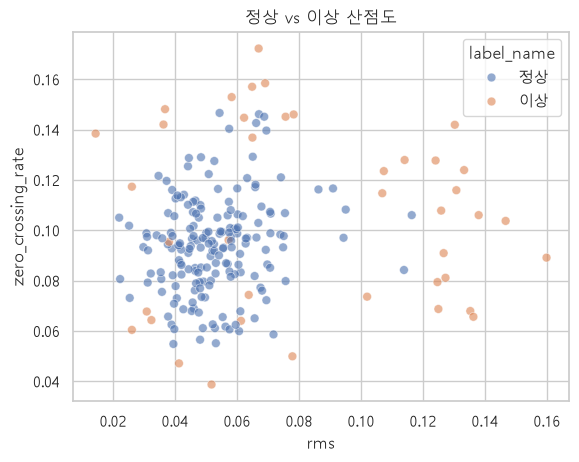

In [16]:
# 색 구분 산점도
sns.scatterplot(data=df, x="rms", y="zero_crossing_rate",
                hue="label_name", alpha=0.6, s=40)
plt.title("정상 vs 이상 산점도")
plt.show()

0.135


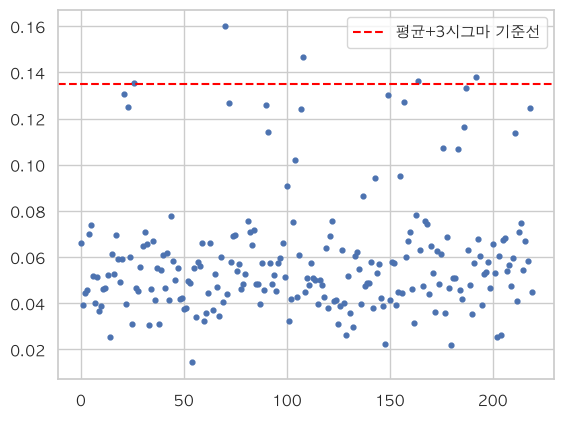

In [ ]:
# 평균+3σ 기준선
thr = df["rms"].mean() + 3 * df["rms"].std()
print(round(thr, 3))
# 출력: 0.134   (rms 평균+3σ 기준값)
plt.scatter(range(len(df)), df["rms"], s=12)
plt.axhline(y=thr, color="red", linestyle="--", label="평균+3시그마 기준선")
plt.legend()
plt.show()

# df["anomaly"] == 1: 데이터프레임(df)에서 이상치로 라벨링된 행(1)만 필터링합니다.

# .sort_values("score"): 필터링된 이상치들을 score(이상치 점수) 기준으로 오름차순 정렬합니다. 점수가 가장 낮은(가장 음수에 가까운) 데이터가 맨 위로 옵니다.

# len(anom_df): 필터링된 이상치 데이터의 총 개수를 집계합니다.

# anom_df["score"].min(): 추출된 이상치들 중 가장 낮은 점수를 구하고, 소수점 3자리까지 반올림(round(..., 3))합니다.

# 2. 출력 결과(도표) 해석
# ① 이상치 : 40 (또는 이상치 개수 : 40개)
# 전체 데이터 세트 중에서 총 40개의 데이터가 이상치(Anomaly)로 분류되었습니다.

# 앞서 설정한 모델 매개변수(contamination=0.18)에 따라, 전체 데이터 중 상위 18%에 해당하는 심각한 데이터 40건이 선별된 결과입니다.

# ② 이상치 최솟값 : -0.678
# 추출된 40개의 이상치 중 가장 심각한(이상 정도가 가장 강한) 데이터의 점수가 -0.678입니다.

# Isolation Forest의 decision_function 점수는 음수 방향으로 멀어질수록 정상 패턴에서 크게 벗어난 강력한 이상치임을 뜻합니다.

# 즉, 정렬된 anom_df 맨 첫 번째 행(Top 1)에 위치한 데이터가 바로 이 -0.678 점수를 가진 데이터입니다.

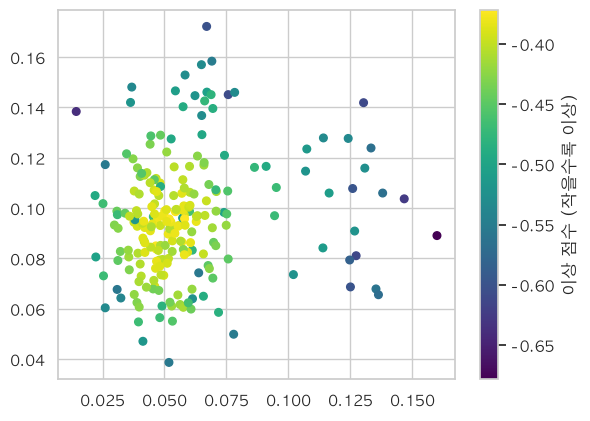

In [12]:
# 이상 점수를 색 농담으로
sc = plt.scatter(df["rms"], df["zero_crossing_rate"], c=df["score"], cmap="viridis", s=30)
plt.colorbar(sc, label="이상 점수 (작을수록 이상)")
plt.show()

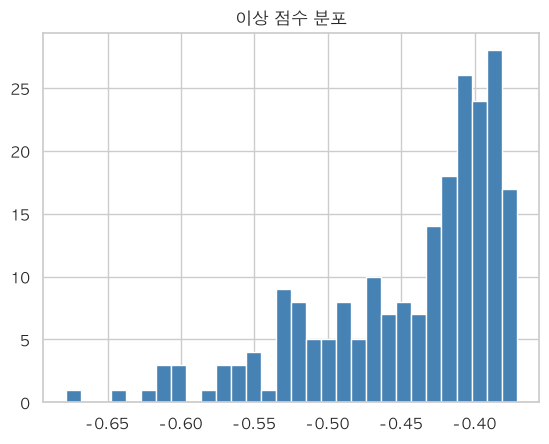

In [13]:
# 이상 점수 히스토그램
plt.hist(df["score"], bins=30, color="steelblue", edgecolor="white")
plt.title("이상 점수 분포")
plt.show()

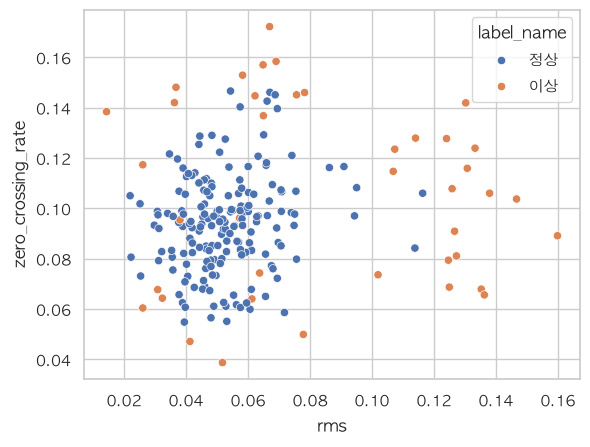

In [ ]:
# 그림 저장(savefig를 show보다 먼저)
sns.scatterplot(data=df, x="rms", y="zero_crossing_rate", hue="label_name")
plt.savefig("anomaly_scatter.png", dpi=150, bbox_inches="tight") # png 로 이미지 저장하는 것이 좋음 왜냐하면 첨부파일이 깨지지 않음
plt.show()

# 실습

In [15]:
# 실습 1 — 이상 라벨 만들고 붙이기
iso = IsolationForest(contamination=0.18, random_state=42)
pred = iso.fit_predict(df[feats])
df["anomaly"] = (pred == -1).astype(int)             # -1(이상)→1
df["label_name"] = df["anomaly"].map({1: "이상", 0: "정상"})
df["score"] = iso.score_samples(df[feats])
print(int(df["anomaly"].sum()))                      # 40
print(df[feats + ["anomaly", "label_name", "score"]].head())

40
      rms  spectral_centroid  zero_crossing_rate  anomaly label_name     score
0  0.0659             1982.7              0.1171        0         정상 -0.416981
1  0.0393             2160.8              0.0821        0         정상 -0.407007
2  0.0443             2065.9              0.0910        0         정상 -0.384584
3  0.0458             1884.4              0.1072        0         정상 -0.392573
4  0.0698             2430.9              0.0864        0         정상 -0.442455


In [16]:
# 실습 2 — 이상 샘플 추출하기
anom_df = df[df["anomaly"] == 1].sort_values("score")  # 점수 작은 순
print(len(anom_df))                                    # 40
print(anom_df[feats + ["score"]].head(5))              # 가장 이상한 5개

40
        rms  spectral_centroid  zero_crossing_rate     score
70   0.1599             1947.0              0.0891 -0.678462
54   0.0144             1864.1              0.1384 -0.638786
108  0.1467             2674.4              0.1037 -0.625262
157  0.1273             1577.0              0.0811 -0.613582
149  0.1303             2126.7              0.1419 -0.610869


In [18]:
# 실습 3 — 정답과 교차표 만들기
ct = pd.crosstab(df["label"], df["anomaly"])
print(ct)
hit = int(ct.loc[1, 1])
fp = int(ct.loc[0, 1])
miss = int(ct.loc[1, 0])
print("맞힘", hit, "거짓경보", fp, "놓침", miss)

anomaly    0   1
label           
0        166  14
1         14  26
맞힘 26 거짓경보 14 놓침 14


In [ ]:
# 실습 4 — 정상·이상 산점도 그리기
sns.scatterplot(data=df, x="rms", y="zero_crossing_rate", hue="label_name")
plt.title("정상 vs 이상 산점도")
plt.xlabel("rms (소리 세기)")
plt.show()